In [1]:
#引入工具包
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
#读入数据
path='.'
    #注意文件夹路径，双斜杠
path_name=os.path.join(path,'data.csv')
    #注意，os.path.join函数，执行路径拼接
    #'C:\\Users\\wdxiaochun\\Desktop\\car_loan\\accepts.csv'

data = pd.read_csv(path_name)
#data = pd.read_csv('data.csv')

In [3]:
#查看样本形状，样本条数，样本属性数量
data.shape

(5845, 25)

In [4]:
#查看数据前5条数据
data.head()

,application_id,account_number,bad_ind,vehicle_year,vehicle_make,bankruptcy_ind,tot_derog,tot_tr,age_oldest_tr,tot_open_tr,...,purch_price,msrp,down_pyt,loan_term,loan_amt,ltv,tot_income,veh_mileage,used_ind,weight
0,2314049,11613,1,1998.0,FORD,N,7.0,9.0,64.0,2.0,...,17200.00,17350.0,0.00,36,17200.00,99.0,6550.00,24000.0,1,1.00
1,63539,13449,0,2000.0,DAEWOO,N,0.0,21.0,240.0,11.0,...,19588.54,19788.0,683.54,60,19588.54,99.0,4666.67,22.0,0,4.75
2,7328510,14323,1,1998.0,PLYMOUTH,N,7.0,10.0,60.0,NaN,...,13595.00,11450.0,0.00,60,10500.00,92.0,2000.00,19600.0,1,1.00
3,8725187,15359,1,1997.0,FORD,N,3.0,10.0,35.0,5.0,...,12999.00,12100.0,3099.00,60,10800.00,118.0,1500.00,10000.0,1,1.00
4,4275127,15812,0,2000.0,TOYOTA,N,0.0,10.0,104.0,2.0,...,26328.04,22024.0,0.00,60,26328.04,122.0,4144.00,14.0,0,4.75


In [5]:
#查看数据大概情况
data.describe().T

,count,mean,std,min,25%,50%,75%,max
application_id,5845.0,5.039359e+06,2.880450e+06,4065.0,2513980.000,5110443.00,7526973.00,10000115.00
account_number,5845.0,5.021740e+06,2.873516e+06,11613.0,2567174.000,4988152.00,7556672.00,10010219.00
bad_ind,5845.0,2.047904e-01,4.035829e-01,0.0,0.000,0.00,0.00,1.00
vehicle_year,5844.0,1.901794e+03,4.880244e+02,0.0,1997.000,1999.00,2000.00,9999.00
tot_derog,5632.0,1.910156e+00,3.274744e+00,0.0,0.000,0.00,2.00,32.00
tot_tr,5632.0,1.708469e+01,1.081406e+01,0.0,9.000,16.00,24.00,77.00
age_oldest_tr,5629.0,1.543043e+02,9.994054e+01,1.0,78.000,137.00,205.00,588.00
tot_open_tr,4426.0,5.720063e+00,3.165783e+00,0.0,3.000,5.00,7.00,26.00
tot_rev_tr,5207.0,3.093336e+00,2.401923e+00,0.0,1.000,3.00,4.00,24.00
tot_rev_debt,5367.0,6.218620e+03,8.657668e+03,0.0,791.000,3009.00,8461.50,96260.00


In [6]:
#观察并通过duplicated方检查发现现application_id account_number都是样本的唯一编号且二者同值，取其一即可
data.loc[:,['application_id','account_number']].duplicated().sum()
data.dtypes

application_id      int64
account_number      int64
bad_ind             int64
vehicle_year      float64
vehicle_make       object
bankruptcy_ind     object
tot_derog         float64
tot_tr            float64
age_oldest_tr     float64
tot_open_tr       float64
tot_rev_tr        float64
tot_rev_debt      float64
tot_rev_line      float64
rev_util            int64
fico_score        float64
purch_price       float64
msrp              float64
down_pyt          float64
loan_term           int64
loan_amt          float64
ltv               float64
tot_income        float64
veh_mileage       float64
used_ind            int64
weight            float64
dtype: object

In [7]:
#分别划分X变量与Y变量
x_list=['vehicle_year', 'vehicle_make', 'bankruptcy_ind', 'tot_derog', 'tot_tr',
            'age_oldest_tr', 'tot_open_tr', 'tot_rev_tr', 'tot_rev_debt', 'tot_rev_line', 'rev_util', 'fico_score', 'purch_price',
            'msrp', 'down_pyt', 'loan_term', 'loan_amt', 'ltv', 'tot_income', 'veh_mileage', 'used_ind', 'weight']
data_x=data.loc[:,x_list]
data_y=data.loc[:,'bad_ind']

In [8]:
#查看Y变量值的分布 正负样本数量
data_y.value_counts()

bad_ind
0    4648
1    1197
Name: count, dtype: int64

In [9]:
#真对X变量进行数据探索
pd.set_option('display.max_columns', None)
data_x_des=data_x.describe(include='all').T
data_x_des

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
vehicle_year,5844.0,NaN,NaN,NaN,1901.793634,488.024392,0.0,1997.0,1999.0,2000.0,9999.0
vehicle_make,5546,154,FORD,1112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bankruptcy_ind,5628,2,N,5180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tot_derog,5632.0,NaN,NaN,NaN,1.910156,3.274744,0.0,0.0,0.0,2.0,32.0
tot_tr,5632.0,NaN,NaN,NaN,17.084695,10.814056,0.0,9.0,16.0,24.0,77.0
age_oldest_tr,5629.0,NaN,NaN,NaN,154.304317,99.94054,1.0,78.0,137.0,205.0,588.0
tot_open_tr,4426.0,NaN,NaN,NaN,5.720063,3.165783,0.0,3.0,5.0,7.0,26.0
tot_rev_tr,5207.0,NaN,NaN,NaN,3.093336,2.401923,0.0,1.0,3.0,4.0,24.0
tot_rev_debt,5367.0,NaN,NaN,NaN,6218.619899,8657.667616,0.0,791.0,3009.0,8461.5,96260.0
tot_rev_line,5367.0,NaN,NaN,NaN,18262.655674,20942.60507,0.0,3235.5,10574.0,26196.0,205395.0


In [10]:
#将变量中文名与变量一一对应，方便后续进行查看
all_list=list(data.columns)
cn_label=['申请者ID','帐户号','是否违约','汽车购买时间','汽车制造商','曾经破产标识','五年内信用不良事件数量','全部帐户数量',
           '账号存续月份数','开户帐户数量','信用卡数量','信用卡欠款余额','信用卡授信额度','信用卡额度使用比例',
           'FICO打分','汽车购买金额','建议售价','分期付款的首次交款','贷款期限','贷款金额','贷款金额/售价','月均收入','行驶里程','是否二手车','样本权重'
           ]
label_dict={}
for i in range(len(all_list)):
    label_dict[all_list[i]]=cn_label[i]

In [11]:
#将label拼接到X变量
label_series=pd.Series(label_dict)
data_x_des['label']=label_series
data_x.isnull().sum()


vehicle_year         1
vehicle_make       299
bankruptcy_ind     217
tot_derog          213
tot_tr             213
age_oldest_tr      216
tot_open_tr       1419
tot_rev_tr         638
tot_rev_debt       478
tot_rev_line       478
rev_util             0
fico_score         314
purch_price          0
msrp                 1
down_pyt             0
loan_term            0
loan_amt             0
ltv                  1
tot_income           5
veh_mileage          1
used_ind             0
weight               0
dtype: int64

In [12]:
###########################
#查看月均收入的总体分布情况和缺失值情况
data_x['tot_income'].value_counts(dropna=False)
data_x['tot_income'].describe().T
data_x['tot_income'].isnull().sum()

np.int64(5)

In [13]:
#查看每项的违约情况
data_y.groupby(data_x['tot_income']).agg(['count','mean'])

,count,mean
tot_income,,
0.00,115,0.173913
4.33,1,0.000000
7.92,1,1.000000
38.00,1,0.000000
66.67,1,0.000000
...,...,...
200000.00,1,0.000000
225000.00,1,0.000000
291666.67,1,0.000000


In [14]:
#缺失值采用中位数填充
data_x['tot_income']=data_x['tot_income'].fillna(data_x['tot_income'].median())

In [15]:
#盖帽处理
q25=data_x['tot_income'].quantile(0.25)
q75=data_x['tot_income'].quantile(0.75)
max_qz=q75+1.5*(q75-q25)
sum(data_x['tot_income']>max_qz)

359

In [16]:
#359 #存在259个样本的取值超过理论极大值，进行盖帽

temp_series=data_x['tot_income']>max_qz
data_x.loc[temp_series,'tot_income']=max_qz
data_x['tot_income'].describe()

count    5845.000000
mean     3982.582701
std      2378.243713
min         0.000000
25%      2220.000000
50%      3400.000000
75%      5150.000000
max      9545.000000
Name: tot_income, dtype: float64

In [17]:
##对信用卡授信额度进行预处理
data_x['tot_rev_line'].value_counts(dropna=False)
data_x['tot_rev_line'].describe().T
data_x['tot_rev_line'].isnull().sum()

np.int64(478)

In [18]:
#查看每项的违约情况
data_y.groupby(data_x['tot_rev_line']).agg(['count','mean'])
data_x['tot_rev_line1']=data_x['tot_rev_line'].fillna('unknown')
data_y.groupby(data_x['tot_rev_line1']).agg(['count','mean'])

,count,mean
tot_rev_line1,,
0.0,127,0.267717
29.0,1,0.000000
35.0,1,0.000000
39.0,1,0.000000
40.0,1,0.000000
...,...,...
147712.0,1,0.000000
157007.0,1,0.000000
163850.0,1,0.000000


In [19]:
#盖帽处理
q25=data_x['tot_rev_line'].quantile(0.25)
q75=data_x['tot_rev_line'].quantile(0.75)
max_qz=q75+1.5*(q75-q25)
sum(data_x['tot_rev_line']>max_qz)

259

In [20]:
#259 #存在259个样本的取值超过理论极大值，进行盖帽

temp_series=data_x['tot_rev_line']>max_qz
data_x.loc[temp_series,'tot_rev_line']=max_qz
data_x['tot_rev_line'].describe()

count     5367.000000
mean     17197.230529
std      17318.002680
min          0.000000
25%       3235.500000
50%      10574.000000
75%      26196.000000
max      60636.750000
Name: tot_rev_line, dtype: float64

In [21]:
#将数据分箱 用999999填充缺失值
data_x['tot_rev_line_fx']=pd.qcut(data_x['tot_rev_line'],10,labels=False,duplicates='drop')
data_x['tot_rev_line_fx']=data_x['tot_rev_line_fx'].fillna(999999)

In [22]:
#查看不同码值对应的违约率情况
data_y.groupby(data_x['tot_rev_line_fx']).agg(['count','mean'])

,count,mean
tot_rev_line_fx,,
0.0,544,0.351103
1.0,530,0.286792
2.0,546,0.271062
3.0,535,0.244860
4.0,529,0.219282
5.0,537,0.182495
6.0,536,0.128731
7.0,536,0.093284
8.0,537,0.093110


In [23]:
#汽车制造年份预处理
#产看其缺失值情况
data_x.loc[:,'vehicle_year'].value_counts().sort_index()
data_x['vehicle_year'].isnull().sum()
data_y.groupby(data_x['vehicle_year']).agg(['count','mean'])

,count,mean
vehicle_year,,
0.0,298,0.208054
1977.0,1,0.000000
1982.0,1,1.000000
1985.0,1,0.000000
1986.0,2,0.500000
1988.0,1,0.000000
1989.0,3,0.333333
1990.0,12,0.083333
1991.0,19,0.052632


In [24]:
#填充缺失值
data_x.loc[:,'vehicle_year'][data_x.loc[:,'vehicle_year'].isin([0,9999])]=np.nan
data_x['vehicle_year']=data_x['vehicle_year'].fillna(data_x['vehicle_year'].median())

C:\Users\jumbo\AppData\Local\Temp\ipykernel_35996\2405121177.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_x.loc[:,'vehicle_year'][data_x.loc[:,'vehicle_year'].isin([0,9999])]=np.nan
C:\Users\jumbo\AppData\Local\Temp\ipykernel_359

In [25]:
#对破产标示进行预处理
data_x['bankruptcy_ind'].value_counts(dropna=False)
data_x['bankruptcy_ind1']=data_x['bankruptcy_ind'].fillna('unknown')
data_y.groupby(data_x['bankruptcy_ind1']).agg(['count','mean'])

,count,mean
bankruptcy_ind1,,
N,5180,0.196332
Y,448,0.229911
unknown,217,0.354839


In [26]:
#重新划分X与Y变量
x_var_list=['tot_derog', 'tot_tr', 'age_oldest_tr', 'tot_open_tr', 'tot_rev_tr', 'tot_rev_debt', 'tot_rev_line', 'rev_util', 'fico_score', 'purch_price',
            'msrp', 'down_pyt', 'loan_term', 'loan_amt', 'ltv', 'tot_income', 'veh_mileage', 'used_ind']
data_x=data.loc[:,x_var_list]
data_y=data.loc[:,'bad_ind']

In [27]:
#用中位数填充缺失值
temp=data_x.median()
temp_dict={} 
for i in range(len(list(temp.index))):
    temp_dict[list(temp.index)[i]]=list(temp.values)[i]    

data_x_fill=data_x.fillna(temp_dict)

In [28]:
#使用train_test_split划分训练集与测试集
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y=train_test_split(data_x_fill, data_y, test_size=0.25, random_state=12345)

In [29]:
#引入线性回归工具包
from sklearn.linear_model import LinearRegression
linear = LinearRegression()

In [30]:
#模型训练
model = linear.fit(train_x,train_y)

In [31]:
#查看相关系数
linear.intercept_
linear.coef_

array([ 4.59905445e-03, -2.39430130e-03, -1.47941826e-04,  2.53458256e-03,
        2.31971609e-03, -2.91112930e-06, -3.45946299e-07,  1.91778076e-04,
       -1.79073491e-03,  9.16546833e-07,  7.33169704e-07,  2.21907936e-06,
       -3.26173321e-04, -1.49059519e-06,  2.89329329e-03, -8.04611063e-08,
       -1.59556068e-08, -4.79689429e-03])

In [32]:
#排序得出权重最大的几个变量
var_coef=pd.DataFrame()
var_coef['var']=x_var_list
var_coef['coef']=linear.coef_
var_coef.sort_values(by='coef', ascending=False)

,var,coef
0,tot_derog,4.599054e-03
14,ltv,2.893293e-03
3,tot_open_tr,2.534583e-03
4,tot_rev_tr,2.319716e-03
7,rev_util,1.917781e-04
11,down_pyt,2.219079e-06
9,purch_price,9.165468e-07
10,msrp,7.331697e-07
16,veh_mileage,-1.595561e-08
15,tot_income,-8.046111e-08


#clf.predict_proba，计算每个样本的预测概率，预测y=0，y=1，提取y=1的一列数据
#注意，roc_curve函数，返回假正率、真正率、门槛值
#基于测试集,进行auc模型评估

In [33]:
import sklearn.metrics as metrics
fpr, tpr, th = metrics.roc_curve(test_y, linear.predict(test_x))
metrics.auc(fpr, tpr)

np.float64(0.7692524355490755)

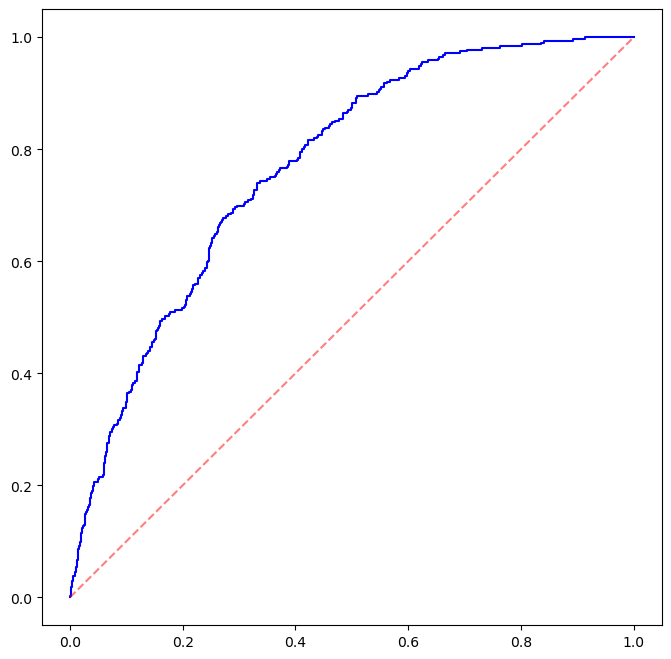

In [34]:
#绘制ROC曲线
import matplotlib.pyplot as plt
plt.figure(figsize=[8, 8])
plt.plot(fpr, tpr, color='b')
plt.plot([0, 1], [0, 1], color='r', alpha=.5, linestyle='--') 
plt.show()

In [35]:
##使用决策树模型进行数据分析
from sklearn.tree import DecisionTreeClassifier, plot_tree
tree = DecisionTreeClassifier()

In [36]:
#模型训练
tree.fit(train_x,train_y)

DecisionTreeClassifier()

In [37]:
#查看树的深度
len(np.unique(tree.apply(train_x)))

646

In [38]:
#查看模型训练效果
fpr, tpr, th = metrics.roc_curve(test_y, tree.predict_proba(test_x.values)[:,1])
metrics.auc(fpr, tpr)

c:\Users\jumbo\.conda\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


np.float64(0.587994565577573)

In [39]:
#调整决策树参数重新构建决策树 重新设置树的最大深度和叶节点大小
tree2 = DecisionTreeClassifier(max_depth=20,min_samples_leaf=100)
tree2.fit(train_x,train_y)

DecisionTreeClassifier(max_depth=20, min_samples_leaf=100)

In [40]:
#查看树的深度
len(np.unique(tree2.apply(train_x)))

32

In [41]:
#查看auc评估指标
fpr, tpr, th = metrics.roc_curve(test_y, tree2.predict_proba(test_x.values)[:,1])
metrics.auc(fpr, tpr)

c:\Users\jumbo\.conda\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


np.float64(0.746244504826916)

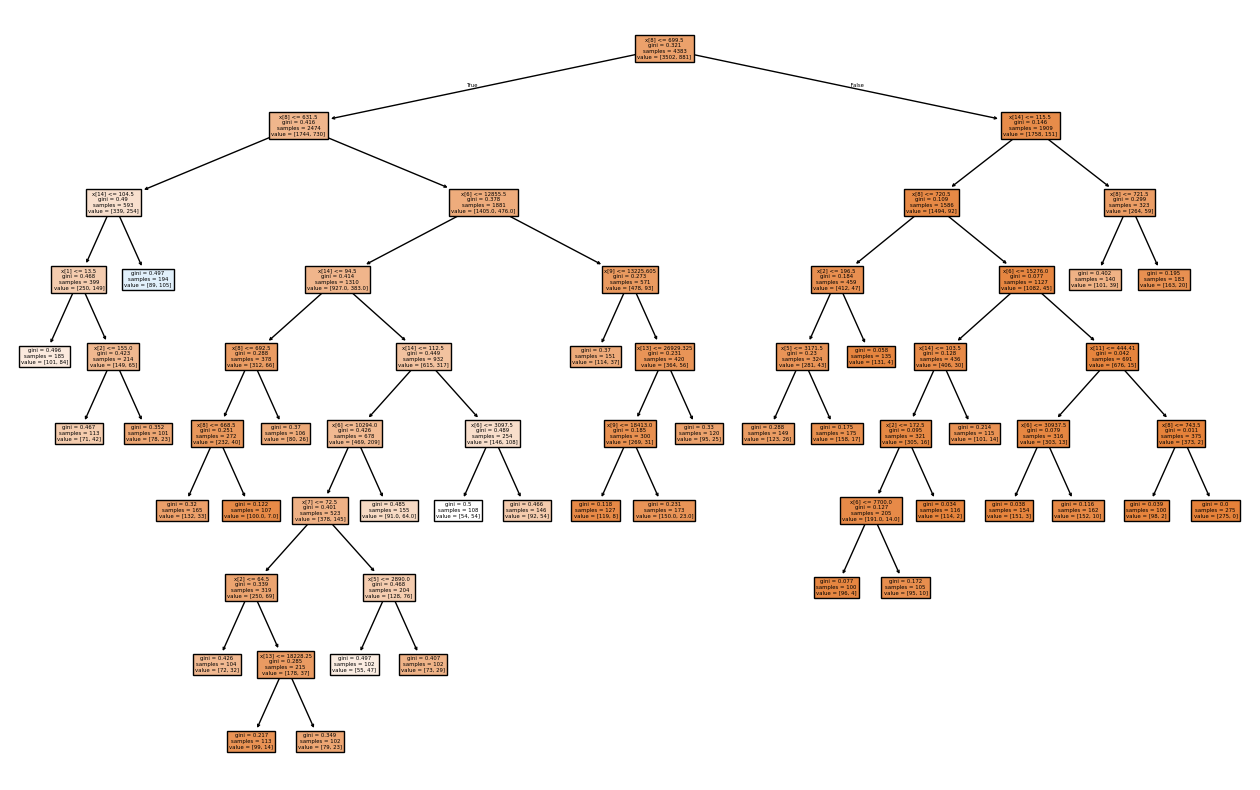

In [42]:
#查看决策树结构
plt.figure(figsize=[16,10])
plot_tree(tree2, filled=True)
    #plot_tree函数，绘制决策树的整体结构
plt.show()

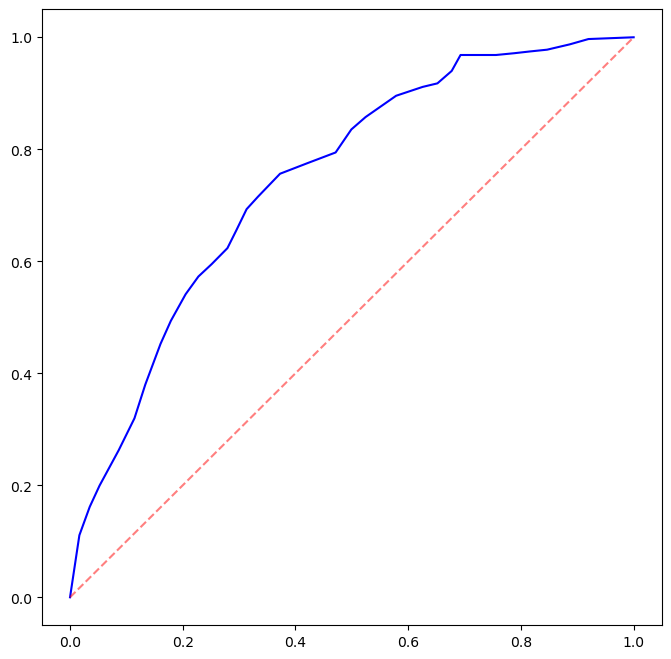

In [43]:
#绘制ROC曲线
plt.figure(figsize=[8, 8])
plt.plot(fpr, tpr, color='b')
plt.plot([0, 1], [0, 1], color='r', alpha=.5, linestyle='--') 
plt.show()

In [44]:
#采用随机森林模型进行分类预测
from sklearn.ensemble import RandomForestClassifier
#forest = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_leaf=100,random_state=11223)
forest =  RandomForestClassifier()

In [45]:
#模型训练
forest.fit(train_x,train_y)

RandomForestClassifier()

In [46]:
#查看auc评估指标
fpr, tpr, th = metrics.roc_curve(test_y, forest.predict_proba(test_x.values)[:,1])
metrics.auc(fpr, tpr)

c:\Users\jumbo\.conda\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


np.float64(0.7579100117083085)

In [47]:
#调参构建新的随机森林
forest1 = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_leaf=100,random_state=11223)

In [48]:
#构建新的随机森林模型
forest1.fit(train_x,train_y)

RandomForestClassifier(max_depth=20, min_samples_leaf=100, random_state=11223)

In [49]:
#查看auc评估指标
fpr, tpr, th = metrics.roc_curve(test_y, forest1.predict_proba(test_x.values)[:,1])
metrics.auc(fpr, tpr)

c:\Users\jumbo\.conda\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


np.float64(0.7636136700024301)

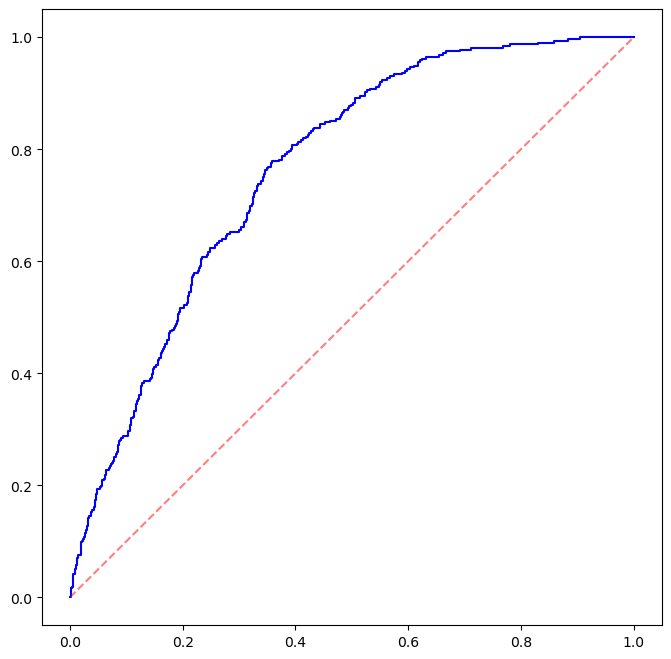

In [50]:
#绘制ROC曲线
plt.figure(figsize=[8, 8])
plt.plot(fpr, tpr, color='b')
plt.plot([0, 1], [0, 1], color='r', alpha=.5, linestyle='--') 
plt.show()